# 05 — Three-Version Comparison Analysis

Compares three versions of the election results to assess OCR accuracy and imputation quality.

| Version | Description |
|---|---|
| **V1** | OCR output + imputation (current clean data) |
| **V2** | V1 proportionally scaled up to reference total |
| **V3** | Ground truth from `reference_constituency.json` / external CSVs |
| **V4** | Impute missing vote with KNNImputer |

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json
from pathlib import Path

plt.rcParams['font.family'] = 'Tahoma'

ROOT         = Path('..').resolve()
CLEAN_PATH   = ROOT / 'data' / 'clean_data'
EXTERNAL     = ROOT / 'data' / 'external'

# ── Load V1 ──────────────────────────────────────────────────────────────────
v1_votes      = pd.read_csv(CLEAN_PATH / '5_18_votes.csv',      encoding='utf-8-sig')
v1_party      = pd.read_csv(CLEAN_PATH / '5_18_party_vote.csv', encoding='utf-8-sig')

# ── Load V3 reference ────────────────────────────────────────────────────────
candidates_ref = pd.read_csv(EXTERNAL / 'candidates.csv', encoding='utf-8-sig')
parties_ref    = pd.read_csv(EXTERNAL / 'parties.csv',    encoding='utf-8-sig')

# ── Load V4 KNN Imputed ────────────────────────────────────────────────────────
v4_votes      = pd.read_csv(CLEAN_PATH / '5_18_votes_KNNImputed.csv',      encoding='utf-8-sig')
v4_party      = pd.read_csv(CLEAN_PATH / '5_18_party_vote_KNNImputed.csv', encoding='utf-8-sig')

print('V1 constituency vote rows:', len(v1_votes))
print('V1 party-list vote rows:  ', len(v1_party))
print('V3 candidates:', len(candidates_ref))
print('V3 parties:   ', len(parties_ref))
print('V4 constituency vote rows:', len(v4_votes))
print('V4 party-list vote rows:  ', len(v4_party))

V1 constituency vote rows: 2002
V1 party-list vote rows:   15939
V3 candidates: 7
V3 parties:    57
V4 constituency vote rows: 2002
V4 party-list vote rows:   15939


In [16]:
# ── V1: aggregate ─────────────────────────────────────────────────────────────
v1_cand = (
    v1_votes.groupby('entity_name')['votes'].sum()
    .reset_index()
    .rename(columns={'votes': 'V1'})
)

v1_party_agg = (
    v1_party.groupby('entity_name')['votes'].sum()
    .reset_index()
    .rename(columns={'votes': 'V1'})
)

# ── V3: from external CSVs ───────────────────────────────────────────────────
v3_cand = candidates_ref[['candidate_name', 'votes_reference']].rename(
    columns={'candidate_name': 'entity_name', 'votes_reference': 'V3'}
)

v3_party = parties_ref[['party_name', 'votes_reference_constituency']].rename(
    columns={'party_name': 'entity_name', 'votes_reference_constituency': 'V3'}
)

# ── V2: proportional scale ───────────────────────────────────────────────────
ref_total_cand  = v3_cand['V3'].sum()
ref_total_party = v3_party['V3'].sum()

v1_total_cand  = v1_cand['V1'].sum()
v1_total_party = v1_party_agg['V1'].sum()

scale_cand  = ref_total_cand  / v1_total_cand
scale_party = ref_total_party / v1_total_party

# ── V4: KNN Imputed ────────────────────────────────────────────────────────
v4_cand = (
    v4_votes.groupby('entity_name')['votes'].sum()
    .reset_index()
    .rename(columns={'votes': 'V4'})
)

v4_party = (
    v4_party.groupby('entity_name')['votes'].sum()
    .reset_index()
    .rename(columns={'votes': 'V4'})
)


print(f'Constituency  — V1 total: {v1_total_cand:,.0f} |V4 total: {v4_cand["V4"].sum():,.0f} | V3 ref: {ref_total_cand:,.0f}  |scale: {scale_cand:.4f}')
print(f'Party-list    — V1 total: {v1_total_party:,.0f} |V4 total: {v4_party["V4"].sum():,.0f} | V3 ref: {ref_total_party:,.0f}  | scale: {scale_party:.4f}')

v1_cand['V2']       = (v1_cand['V1']       * scale_cand ).round().astype('Int64')
v1_party_agg['V2']  = (v1_party_agg['V1']  * scale_party).round().astype('Int64')

Constituency  — V1 total: 64,440 |V4 total: 69,255 | V3 ref: 79,326  |scale: 1.2310
Party-list    — V1 total: 67,963 |V4 total: 71,443 | V3 ref: 79,374  | scale: 1.1679


In [36]:
# ── Candidate comparison table ───────────────────────────────────────────────
cand_compare = (
    v1_cand
    .merge(v3_cand, on='entity_name', how='outer')
    .merge(v4_cand, on='entity_name', how='outer')
    .sort_values('V3', ascending=False)
    .reset_index(drop=True)
)


cand_compare['V1_accuracy%'] = (cand_compare['V1'] / cand_compare['V3'] * 100).round(1)
cand_compare['V2_accuracy%'] = (cand_compare['V2'] / cand_compare['V3'] * 100).round(1)
cand_compare['V4_accuracy%'] = (cand_compare['V4'] / cand_compare['V3'] * 100).round(1)

print('=== Constituency Candidate Comparison ===')
print(cand_compare.to_string(index=False))


=== Constituency Candidate Comparison ===
                entity_name      V1    V2    V3      V4  V1_accuracy%  V2_accuracy%  V4_accuracy%
      นายเชิงชาย ชาลีรินทร์ 45546.0 56067 54996 45843.0          82.8         101.9          83.4
      นางสาววาสนา อยู่ภักดี 10183.0 12535 14658 10441.0          69.5          85.5          71.2
        นายทัศนัย สุขประสาร  3221.0  3965  3538  3670.0          91.0         112.1         103.7
         นายโสโชค สู้โนนตาด  1569.0  1931  1879  3246.0          83.5         102.8         172.8
          นายถวัลย์ หงษ์ไทย  1108.0  1364  1687  1452.0          65.7          80.9          86.1
                ณรงค์ แขนอก  1628.0  2004  1314  2289.0         123.9         152.5         174.2
นายประเสริฐศักดิ์ ขำหินตั้ง  1185.0  1459  1254  2314.0          94.5         116.3         184.5


In [34]:
# ── Party-list comparison table ──────────────────────────────────────────────
party_compare = (
    v1_party_agg
    .merge(v3_party, on='entity_name', how='outer')
    # Bring V4 into the exact same table using another merge:
    .merge(v4_party[['entity_name', 'V4']], on='entity_name', how='outer') 
    .sort_values('V3', ascending=False)
    .reset_index(drop=True)
)

party_compare['V1_accuracy%'] = (party_compare['V1'] / party_compare['V3'] * 100).round(1)
party_compare['V2_accuracy%'] = (party_compare['V2'] / party_compare['V3'] * 100).round(1)
party_compare['V4_accuracy%'] = (party_compare['V4'] / party_compare['V3'] * 100).round(1)

print('=== Top 15 Parties Comparison ===')
print(party_compare.head(15).to_string(index=False))


=== Top 15 Parties Comparison ===
    entity_name      V1    V2    V3      V4  V1_accuracy%  V2_accuracy%  V4_accuracy%
       เพื่อไทย 19715.0 23025 25099 19920.0          78.5          91.7          79.4
        ประชาชน 13425.0 15679 20039 13525.0          67.0          78.2          67.5
      ภูมิใจไทย  6291.0  7347  7952  6343.0          79.1          92.4          79.8
       เศรษฐกิจ  3906.0  4562  4338  3973.0          90.0         105.2          91.6
           ใหม่  3207.0  3745  3813  3234.0          84.1          98.2          84.8
   ประชาธิปัตย์  2714.0  3170  3597  2751.0          75.5          88.1          76.5
   เพื่อชาติไทย  2879.0  3362  3046  2917.0          94.5         110.4          95.8
รวมไทยสร้างชาติ  1334.0  1558  1659  1415.0          80.4          93.9          85.3
       รวมใจไทย   776.0   906   883   814.0          87.9         102.6          92.2
 รวมพลังประชาชน   661.0   772   752   709.0          87.9         102.7          94.3
ประชาธิปไตยใหม่   64

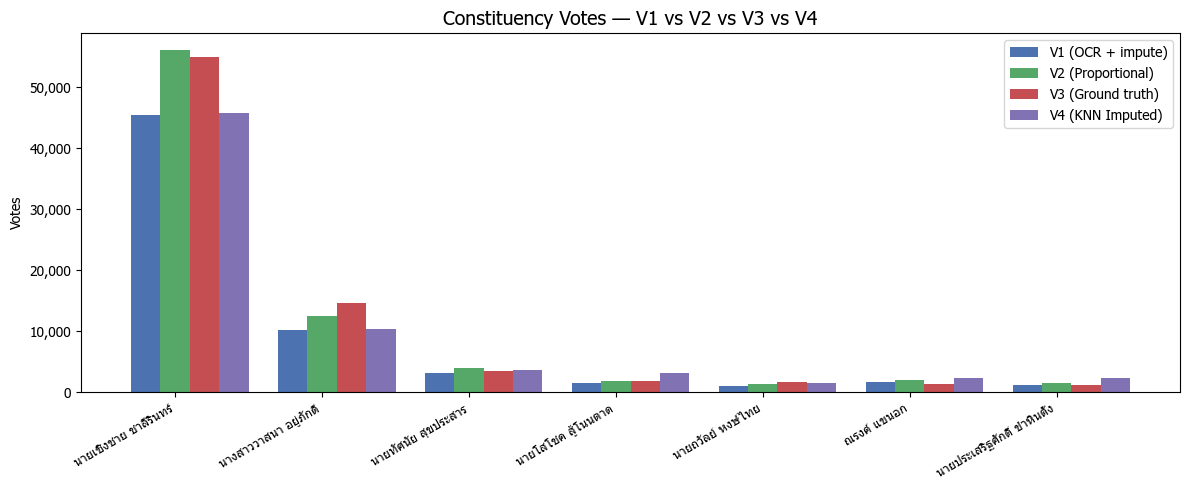

In [37]:
# ── Candidate bar chart ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(cand_compare))
w = 0.2

ax.bar(x - w,   cand_compare['V1'], w, label='V1 (OCR + impute)', color='#4C72B0')
ax.bar(x,       cand_compare['V2'], w, label='V2 (Proportional)', color='#55A868')
ax.bar(x + w,   cand_compare['V3'], w, label='V3 (Ground truth)', color='#C44E52')
ax.bar(x + 2*w, cand_compare['V4'], w, label='V4 (KNN Imputed)', color='#8172B3')   

ax.set_xticks(x)
ax.set_xticklabels(cand_compare['entity_name'], rotation=30, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val:,.0f}'))
ax.set_title('Constituency Votes — V1 vs V2 vs V3 vs V4', fontsize=14)
ax.set_ylabel('Votes')
ax.legend()
plt.tight_layout()
plt.show()

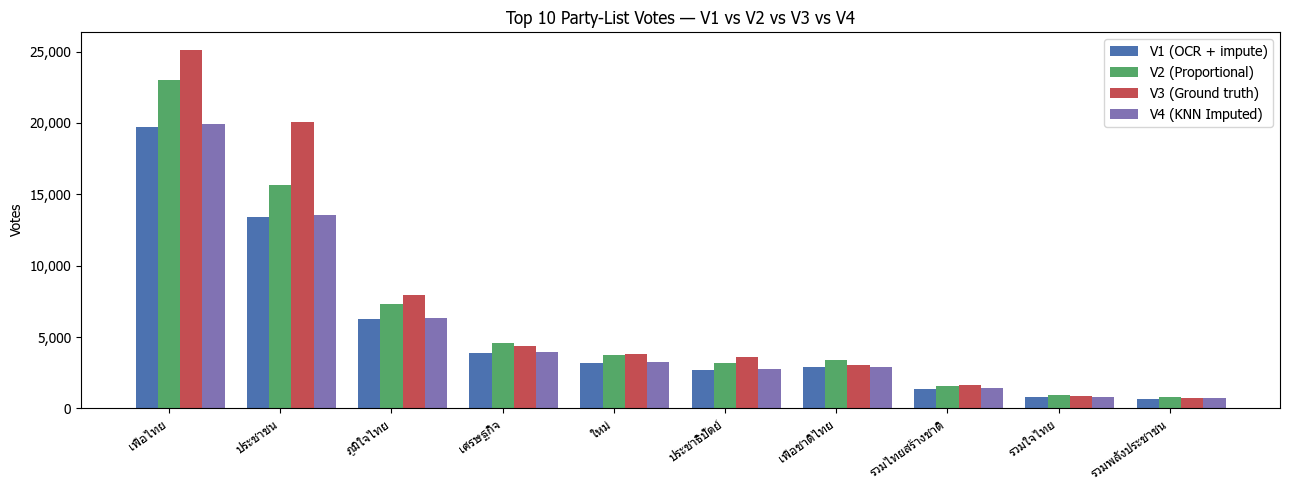

In [39]:
# ── Top 10 parties bar chart ──────────────────────────────────────────────────
top10 = party_compare[party_compare['V3'].notnull()].head(10)



fig, ax = plt.subplots(figsize=(13, 5))

x = np.arange(len(top10))
w = 0.2

ax.bar(x - w,   top10['V1'], w, label='V1 (OCR + impute)', color='#4C72B0')
ax.bar(x,       top10['V2'], w, label='V2 (Proportional)', color='#55A868')
ax.bar(x + w,   top10['V3'], w, label='V3 (Ground truth)', color='#C44E52')
ax.bar(x + 2*w, top10['V4'], w, label='V4 (KNN Imputed)', color='#8172B3')


ax.set_xticks(x)
ax.set_xticklabels(top10['entity_name'], rotation=35, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{val:,.0f}'))
ax.set_title('Top 10 Party-List Votes — V1 vs V2 vs V3 vs V4')
ax.set_ylabel('Votes')
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
# ── Winner & margin summary ───────────────────────────────────────────────────
print('=' * 55)
print('WINNER & MARGIN SUMMARY')
print('=' * 55)

for ver in ['V1', 'V2', 'V3', 'V4']:
    top2 = cand_compare.nlargest(2, ver).reset_index(drop=True)
    winner = top2.loc[0, 'entity_name']
    margin = top2.loc[0, ver] - top2.loc[1, ver]
    total  = cand_compare[ver].sum()
    pct    = margin / total * 100
    print(f'\n{ver}: Winner = {winner}')
    print(f'     Margin = {margin:,.0f} votes ({pct:.1f}% of total)')

print()
print('=' * 55)
print('OVERALL OCR COVERAGE')
print('=' * 55)
print(f'Constituency : {v1_total_cand/ref_total_cand*100:.1f}%  ({v1_total_cand:,.0f} / {ref_total_cand:,.0f})')
print(f'Party-list   : {v1_total_party/ref_total_party*100:.1f}%  ({v1_total_party:,.0f} / {ref_total_party:,.0f})')

WINNER & MARGIN SUMMARY

V1: Winner = นายเชิงชาย ชาลีรินทร์
     Margin = 35,363 votes (54.9% of total)

V2: Winner = นายเชิงชาย ชาลีรินทร์
     Margin = 43,532 votes (54.9% of total)

V3: Winner = นายเชิงชาย ชาลีรินทร์
     Margin = 40,338 votes (50.9% of total)

V4: Winner = นายเชิงชาย ชาลีรินทร์
     Margin = 35,402 votes (51.1% of total)

OVERALL OCR COVERAGE
Constituency : 81.2%  (64,440 / 79,326)
Party-list   : 85.6%  (67,963 / 79,374)
